In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, HuberRegressor, RANSACRegressor, TheilSenRegressor, SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import PredictionErrorDisplay

In [87]:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Salary Data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "rkiattisak/salaly-prediction-for-beginer",
  file_path,
)

print("First 5 records:", df.head())

/tmp/ipykernel_4003/2150386848.py:9: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'salaly-prediction-for-beginer' dataset.
First 5 records:       Age  Gender Education Level          Job Title  Years of Experience  \
0 32.0000    Male      Bachelor's  Software Engineer               5.0000   
1 28.0000  Female        Master's       Data Analyst               3.0000   
2 45.0000    Male             PhD     Senior Manager              15.0000   
3 36.0000  Female      Bachelor's    Sales Associate               7.0000   
4 52.0000    Male        Master's           Director              20.0000   

       Salary  
0  90000.0000  
1  65000.0000  
2 150000.0000  
3  60000.0000  
4 200000.0000  


In [88]:
df.info()

le = LabelEncoder()

for column in ['Gender', 'Education Level', 'Job Title']:
  if column in df.columns:
    df[column] = le.fit_transform(df[column])

print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB
      Age  Gender  Education Level  Job Title  Years of Experience      Salary
0 32.0000       1                0        159               5.0000  90000.0000
1 28.0000       0                1         17               3.0000  65000.0000
2 45.0000       1                2        130              15.0000 150000.0000
3 36.0000       0                0        101               7.0000  60000.0000
4 52.0000       1                1         22   

In [89]:
df.dropna(inplace=True)
y = df['Salary']
X = df.drop('Salary', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


:Zbuduj model benchmarkowy - zwykłą regresję liniową:

In [90]:
regressor = LinearRegression().fit(X_train, y_train)
print(f"Współczynniki: {regressor.coef_}")
print(f"Wyraz wolny: {regressor.intercept_}")
print(f" R^2 {regressor.score(X_train, y_train)}")
print(f"Średni błąd absolutny z treningu: {mean_absolute_error(y_train, regressor.predict(X_train)):.2f}")

y_pred = regressor.predict(X_test)
print(f"Średni błąd kwadratowy: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Średni błąd absolutny: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Wyjaśniona wariancja: {explained_variance_score(y_test, y_pred):.2f}")

Współczynniki: [ 3400.65625     7384.17507075 15289.75305615    38.30848175
  2155.12465162]
Wyraz wolny: -63972.08387966572
 R^2 0.9043289032978942
Średni błąd absolutny z treningu: 11171.01
Średni błąd kwadratowy: 252493731.92
Średni błąd absolutny: 11377.18
Wyjaśniona wariancja: 0.89


Sprawdź czy w danych występuje współliniowość współczynnikiem VIF



In [91]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data)

               feature     VIF
0                  Age 15.1913
1               Gender  2.0598
2      Education Level  2.4033
3            Job Title  4.8656
4  Years of Experience  9.4792


In [92]:
df = df.drop(columns=['Age'])

*Spróbuj* poprawić wynik używając regresji LASSO

In [93]:
lasso_model = Lasso(alpha=0.99)
lasso_model.fit(X_train, y_train)

Lasso(alpha=0.99)

In [94]:
print(f"Współczynniki: {regressor.coef_}")
print(f"Wyraz wolny: {regressor.intercept_}")
print(f" R^2 {regressor.score(X_train, y_train)}")
print(f"Średni błąd absolutny z treningu: {mean_absolute_error(y_train, regressor.predict(X_train)):.2f}")

y_pred = regressor.predict(X_test)
print(f"Średni błąd kwadratowy: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Średni błąd absolutny: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Wyjaśniona wariancja: {explained_variance_score(y_test, y_pred):.2f}")

Współczynniki: [ 3400.65625     7384.17507075 15289.75305615    38.30848175
  2155.12465162]
Wyraz wolny: -63972.08387966572
 R^2 0.9043289032978942
Średni błąd absolutny z treningu: 11171.01
Średni błąd kwadratowy: 252493731.92
Średni błąd absolutny: 11377.18
Wyjaśniona wariancja: 0.89


regresja wielomianowa stopnia 2 i 3

In [95]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

model_poly_2 = make_pipeline(
    PolynomialFeatures(degree=2),
    Lasso(alpha=1.0)
)

model_poly_3 = make_pipeline(
    PolynomialFeatures(degree=3),
    Lasso(alpha=1.0)
)

# Dopasowujemy do danych (X to Twoje cechy, y to Salary)
model_poly_2.fit(X, y)
model_poly_3.fit(X, y)

# Sprawdzamy, ile cech stworzył PolynomialFeatures
n_features_2 = len(model_poly_2.named_steps['polynomialfeatures'].get_feature_names_out())
n_features_3 = len(model_poly_3.named_steps['polynomialfeatures'].get_feature_names_out())
print(f"Liczba wygenerowanych cech (2): {n_features_2}")
print(f"Liczba wygenerowanych cech (3): {n_features_3}")

Liczba wygenerowanych cech (2): 21
Liczba wygenerowanych cech (3): 56


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.379e+10, tolerance: 8.657e+07
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.857e+10, tolerance: 8.657e+07
  model = cd_fast.enet_coordinate_descent(


Regresja k-NN

In [96]:
from sklearn.neighbors import KNeighborsRegressor

model_knn = make_pipeline(
    StandardScaler(),
    KNeighborsRegressor(n_neighbors=5)
)

model_knn.fit(X_train, y_train)
predictions = model_knn.predict(X_test)

Porównanie błędów

In [97]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error

models = {
    "Lasso": lasso_model,
    "Wielomianowa 2st": model_poly_2,
    "Wielomianowa 3st": model_poly_3,
    "k-NN": model_knn
}

# 3. Teraz pętla przejdzie bez problemu
print("--- PORÓWNANIE BŁĘDÓW ---")
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    # Obliczamy metryki
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    evs = explained_variance_score(y_test, y_pred)

    # Dodajemy do listy
    results.append({
        "Model": name,
        "Średni błąd absolutny": round(mae, 2),
        "Średni błąd kwadratowy": round(mse, 2),
        "Wyjaś. wariancja": round(evs, 4)
    })

# Tworzymy DataFrame i wyświetlamy tabelę
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

--- PORÓWNANIE BŁĘDÓW ---
           Model  Średni błąd absolutny  Średni błąd kwadratowy  Wyjaś. wariancja
           Lasso             11377.1700          252499042.7500            0.8883
Wielomianowa 2st              9708.6300          183600198.0800            0.9188
Wielomianowa 3st              9144.5700          153278767.1100            0.9322
            k-NN             10854.0200          234578772.3200            0.8966


narysyj wykres typu scatterplot, dla zmiennych lata doswiadczenia i płaca, czy regresja wyższego rzędu jest uzasadniona?

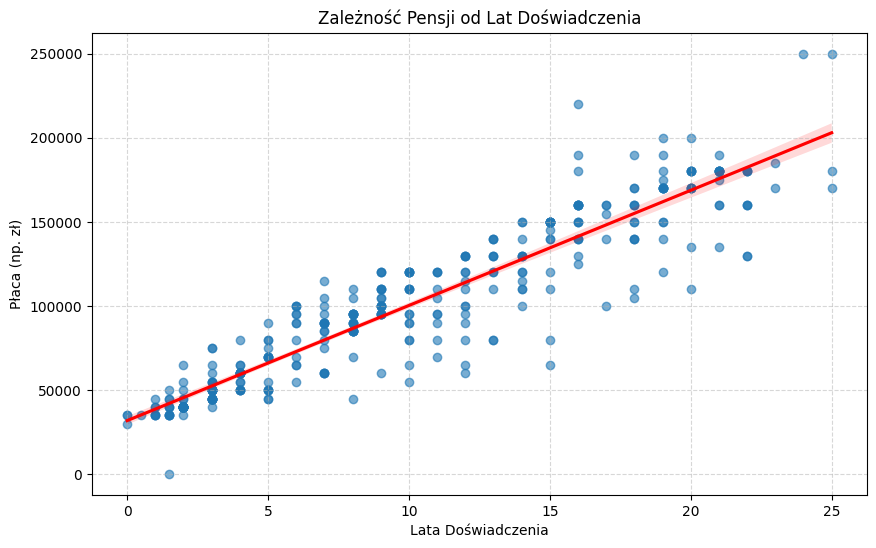

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.regplot(x='Years of Experience', y='Salary', data=df,
            scatter_kws={'alpha': 0.6},
            line_kws={'color': 'red'})

plt.title('Zależność Pensji od Lat Doświadczenia')
plt.xlabel('Lata Doświadczenia')
plt.ylabel('Płaca (np. zł)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()